# Coaxial gen+cost — East Coast, 2011–2020, single depth (50 m)

Gridded `EastCoast_Current_{year}.npz` in (streamed, never loaded whole); one file per
design out, named `coax_{kW}kW_{RFS}mRFS`. Unlike kites, coaxial power is
**depth-independent** — a 1D velocity curve — so output is flat `Energy_pu (time, sites)`
at one operating depth, matching the existing `_50m` files.

Site filter (seafloor 50–2000 m, distance < 200 km) is applied first, same as kites.

In [1]:
# ================= CONFIG =================
import os, glob, zipfile, time
import numpy as np, pandas as pd
from numpy.lib import format as npformat

BASE = r"C:\Users\rmiller9\Documents\East Coast Model"
os.chdir(BASE)
from GeneralGeoTools_EastCoast import GetDepth, GetDistanceToShore

CUR_DIR  = BASE + r"\Resource Data\Current\EastCoast"
SURF_DIR = BASE + r"\Tech Designs\Coaxial"
OUT_DIR  = BASE + r"\Tech Outputs\Coaxial"
TMP_DIR  = CUR_DIR + r"\_coax_tmp"
COASTLINE = BASE + r"\Geospatial Data\CoastLine\ne_10m_coastline.shp"

YEARS = list(range(2011, 2021))
DESIGN_IDS = [0, 1, 2, 3]
OPERATING_DEPTH = 50                 # m — single layer read from the current data
VELOCITY_BINS = np.arange(0.5, 0.5 + 10*0.25, 0.25)   # coaxial fixed grid (from the tool)

SEAFLOOR_MIN, SEAFLOOR_MAX = 50.0, 2000.0
MAX_DIST_KM = 200.0
FCR = 0.10
RES_DEG, RES_KM = 0.08, 8
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(TMP_DIR, exist_ok=True)

def cur_file(y): return os.path.join(CUR_DIR, f"EastCoast_Current_{y}.npz")
for y in YEARS: assert os.path.exists(cur_file(y)), f"missing {cur_file(y)}"
depth_axis = np.load(cur_file(YEARS[0]), allow_pickle=True)["depth"]
DEPTH_IDX = int(np.where(depth_axis == OPERATING_DEPTH)[0][0])
print(f"operating depth {OPERATING_DEPTH} m -> current index {DEPTH_IDX}")
print(f"velocity bins: {VELOCITY_BINS}")

operating depth 50 m -> current index 2
velocity bins: [0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75]


## Helpers

In [2]:
def _hdr(fp):
    v=npformat.read_magic(fp)
    try: return npformat._read_array_header(fp,v)
    except AttributeError:
        return npformat.read_array_header_1_0(fp) if v==(1,0) else npformat.read_array_header_2_0(fp)

def stream_current(path, depth_idx, keep_cols=None, block=200):
    """Yield (r0,r1,(nb,n_cols)) of ocean_speed at ONE depth, streamed."""
    with zipfile.ZipFile(path) as zf, zf.open("ocean_speed.npy") as f:
        shape,fort,dt=_hdr(f); T,ND,NLA,NLO=shape; per_t=ND*NLA*NLO; it=dt.itemsize; ncell=NLA*NLO
        for r0 in range(0,T,block):
            r1=min(r0+block,T); nb=r1-r0
            arr=np.frombuffer(f.read(nb*per_t*it),dt).reshape(nb,ND,NLA,NLO)[:,depth_idx,:,:].reshape(nb,ncell)
            yield r0, r1, (arr[:,keep_cols] if keep_cols is not None else arr)

def n_time(path):
    with zipfile.ZipFile(path) as zf, zf.open("ocean_speed.npy") as f:
        return _hdr(f)[0][0]

def _vfmt(v):
    s=f"{v:g}"; return s if "." in s else s+".0"

def load_design(did):
    power=np.loadtxt(os.path.join(SURF_DIR,f"design{did}coax.csv"))
    capex_pkw,opex_pkw,rated=np.loadtxt(os.path.join(SURF_DIR,f"design{did}coax_costAndDeviceInfo.csv"))
    rfs=VELOCITY_BINS[np.argmax(power>=0.99*rated)]         # plateau velocity = RFS
    name=f"coax_{round(float(rated))}kW_{_vfmt(rfs)}mRFS"
    # coaxial interpolator: prepend (0,0); linear; below->0, above->plateau (fill_value)
    v_ext=np.concatenate([[0.0],VELOCITY_BINS]); p_ext=np.concatenate([[0.0],power])
    return dict(name=name, v_ext=v_ext, p_ext=p_ext, plateau=float(power[-1]),
                capex=float(capex_pkw)*float(rated)*1000, opex=float(opex_pkw)*float(rated)*1000,
                rated=float(rated))

def coax_power(speed, d):
    """np.interp with coaxial fill: 0 below range, plateau above range."""
    P=np.interp(speed, d["v_ext"], d["p_ext"])   # np.interp already clamps to endpoints
    return P                                      # endpoints are (0, plateau) -> matches interp1d fill_value

## Site filter (run first) — land mask + seafloor depth + distance

In [3]:
D0=np.load(cur_file(YEARS[0]),allow_pickle=True); lat,lon=D0["lat"],D0["lon"]; D0.close()
ncell=len(lat)*len(lon)
lon_m,lat_m=np.meshgrid(lon,lat)
LatLong_all=np.column_stack([lat_m.ravel(),lon_m.ravel()]).astype(np.float32)

print("land mask (year 1)...")
valid=np.zeros(ncell,bool)
for r0,r1,a in stream_current(cur_file(YEARS[0]), DEPTH_IDX):
    valid |= np.any(~np.isnan(a),axis=0)
ocean_cols=np.flatnonzero(valid)
print(f"  {ncell:,} cells -> {ocean_cols.size:,} ocean cells at {OPERATING_DEPTH} m")

ll=LatLong_all[ocean_cols]
print("GetDepth ...");          t0=time.time(); depth_sea=np.abs(np.asarray(GetDepth(BASE,ll),float));          print(f"  {time.time()-t0:.0f}s")
print("GetDistanceToShore ..."); t0=time.time(); dist=np.asarray(GetDistanceToShore(BASE,ll,CoastlineShpPath=COASTLINE),float); print(f"  {time.time()-t0:.0f}s")

site_ok=(depth_sea>=SEAFLOOR_MIN)&(depth_sea<=SEAFLOOR_MAX)&(dist<MAX_DIST_KM)
keep_cols=ocean_cols[site_ok]
LatLong=LatLong_all[keep_cols]; Depth_keep=depth_sea[site_ok]; Dist_keep=dist[site_ok]
n_keep=keep_cols.size
print(f"seafloor [{SEAFLOOR_MIN},{SEAFLOOR_MAX}] & dist<{MAX_DIST_KM}: {ocean_cols.size:,} -> {n_keep:,} sites")

land mask (year 1)...
  70,929 cells -> 37,319 ocean cells at 50 m
GetDepth ...

 Calculating water depth at each point


100%|██████████| 3732/3732 [15:31<00:00,  4.01it/s]


  947s
GetDistanceToShore ...

 Calculating distance to shore for viable site locations


100%|██████████| 1866/1866 [02:56<00:00, 10.58it/s]

  196s
seafloor [50.0,2000.0] & dist<200.0: 37,319 -> 8,924 sites


## Pass 1 — extract the operating-depth current for filtered sites

In [4]:
year_len=[]; datetimes=[]
for y in YEARS:
    tp=os.path.join(TMP_DIR,f"_curr_{y}.npy")
    T=n_time(cur_file(y)); year_len.append(T)
    datetimes.append(np.load(cur_file(y),allow_pickle=True)["datetime"])
    if os.path.exists(tp): print(f"  {y}: temp exists"); continue
    mm=npformat.open_memmap(tp,mode="w+",dtype=np.float16,shape=(T,n_keep))
    t0=time.time()
    for r0,r1,a in stream_current(cur_file(y), DEPTH_IDX, keep_cols):
        mm[r0:r1]=np.where(np.isnan(a),0.0,a).astype(np.float16)
    mm.flush(); del mm
    print(f"  {y}: {T} steps -> temp ({time.time()-t0:.0f}s)")

TimeList=np.concatenate(datetimes); T_total=int(sum(year_len))
print(f"T_total={T_total:,}, sites={n_keep:,}")

  2011: 2920 steps -> temp (9s)
  2012: 2928 steps -> temp (9s)
  2013: 2920 steps -> temp (9s)
  2014: 2920 steps -> temp (9s)
  2015: 2920 steps -> temp (9s)
  2016: 2928 steps -> temp (9s)
  2017: 2920 steps -> temp (9s)
  2018: 2920 steps -> temp (9s)
  2019: 2920 steps -> temp (9s)
  2020: 2928 steps -> temp (10s)
T_total=29,224, sites=8,924


## Pass 2 — evaluate each design

In [5]:
def evaluate_design(did):
    d=load_design(did)
    out_path=os.path.join(OUT_DIR,f"{d['name']}.npz")
    print("="*64); print(f"design {did} -> {d['name']}")
    if os.path.exists(out_path): print("  exists, skip"); return

    epu_tmp=os.path.join(TMP_DIR,f"_epu_{did}.npy")
    Energy_pu=npformat.open_memmap(epu_tmp,mode="w+",dtype=np.float16,shape=(T_total,n_keep))
    off=0; t0=time.time()
    for y,yl in zip(YEARS,year_len):
        cur=np.load(os.path.join(TMP_DIR,f"_curr_{y}.npy")).astype(np.float32)
        P=coax_power(cur, d)
        Energy_pu[off:off+yl,:]=(P/d["rated"]).astype(np.float16)
        off+=yl
    print(f"  power {time.time()-t0:.0f}s")

    CF=np.asarray(Energy_pu,np.float32).mean(axis=0)
    annual_cost=FCR*d["capex"]+d["opex"]
    annual_energy_mwh=CF*d["rated"]*8760/1000.0
    with np.errstate(divide="ignore",invalid="ignore"):
        LCOE=np.where(annual_energy_mwh>0, annual_cost/annual_energy_mwh, np.inf)

    np.savez_compressed(out_path,
        Energy_pu=np.asarray(Energy_pu),
        LatLong=LatLong, Depth=Depth_keep, DistanceShore=Dist_keep.astype(np.float16),
        AnnualizedCost=np.full(n_keep,(FCR*d["capex"]+d["opex"])/1e6,np.float32),
        RatedPower=np.float64(d["rated"]/1000.0),
        TimeList=TimeList, NumberOfCellsPerSite=np.ones(n_keep),
        ResolutionDegrees=np.float32(RES_DEG), ResolutionKm=np.float32(RES_KM),
        ValidSites=np.ones(n_keep,bool), LCOE=LCOE.astype(np.float16),
        CapacityFactor=CF.astype(np.float16), Depth_m=np.float64(OPERATING_DEPTH),
        CAPEX=d["capex"], OPEX=d["opex"])
    del Energy_pu; os.remove(epu_tmp)
    finite=np.isfinite(LCOE)
    print(f"  saved {d['name']}.npz  ({n_keep:,} sites, {os.path.getsize(out_path)/1024**3:.2f} GB) "
          f"| mean CF {CF.mean():.3f} | median LCOE ${np.median(LCOE[finite]):.0f}")

for did in DESIGN_IDS: evaluate_design(did)
for y in YEARS:
    tp=os.path.join(TMP_DIR,f"_curr_{y}.npy")
    if os.path.exists(tp): os.remove(tp)
print("Done.")

design 0 -> coax_600kW_1.0mRFS
  power 8s


C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_145112\2865207188.py:30: RuntimeWarning: overflow encountered in cast
  ValidSites=np.ones(n_keep,bool), LCOE=LCOE.astype(np.float16),


  saved coax_600kW_1.0mRFS.npz  (8,924 sites, 0.39 GB) | mean CF 0.139 | median LCOE $1498
design 1 -> coax_1000kW_1.5mRFS
  power 7s
  saved coax_1000kW_1.5mRFS.npz  (8,924 sites, 0.42 GB) | mean CF 0.068 | median LCOE $5000
design 2 -> coax_1750kW_1.75mRFS
  power 7s
  saved coax_1750kW_1.75mRFS.npz  (8,924 sites, 0.42 GB) | mean CF 0.046 | median LCOE $7942
design 3 -> coax_2000kW_1.75mRFS
  power 7s
  saved coax_2000kW_1.75mRFS.npz  (8,924 sites, 0.42 GB) | mean CF 0.046 | median LCOE $7896
Done.


4 designs


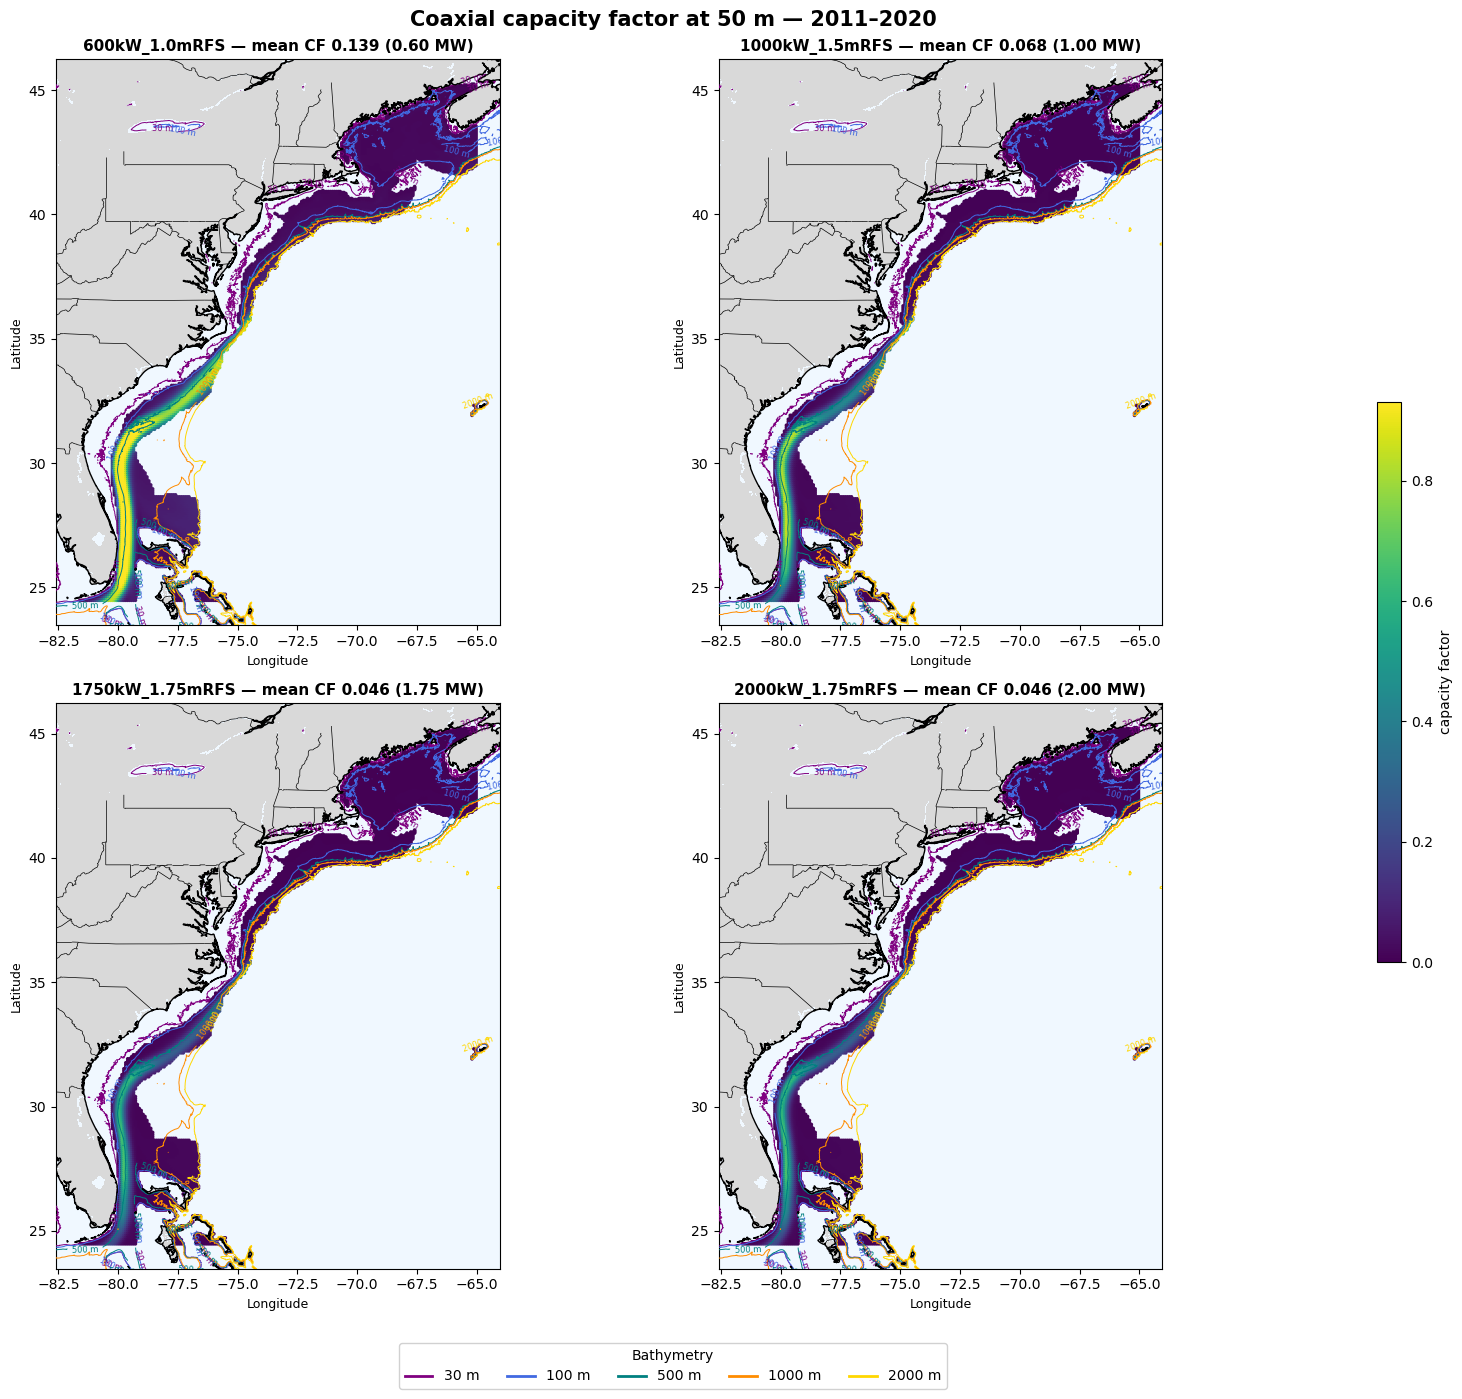

In [6]:
import numpy as np, glob, os, re
import geopandas as gpd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Coaxial"
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
DEPTH_LEVELS=[30,100,500,1000,2000]
DEPTH_COLORS={30:"purple",100:"royalblue",500:"teal",1000:"darkorange",2000:"gold"}

# geo overlays (once)
ds=xr.open_dataset(DEPTH_NC); lat_d=ds["lat"].values[::2]; lon_d=ds["lon"].values[::2]
depth=ds["depth"].values[::2,::2]; LonGrid,LatGrid=np.meshgrid(lon_d,lat_d); ds.close()
coast=gpd.read_file(COAST_SHP); borders=gpd.read_file(BORDERS_SHP)
coast=coast.set_crs(4326) if coast.crs is None else coast.to_crs(4326)
borders=borders.set_crs(4326) if borders.crs is None else borders.to_crs(4326)

# load designs (CF/coords are small — no streaming), ordered by rated kW
files=sorted(glob.glob(os.path.join(OUT_DIR,"coax_*.npz")),
             key=lambda p:int(re.search(r"coax_(\d+)kW",p).group(1)))
data=[]
for p in files:
    D=np.load(p,allow_pickle=True)
    data.append(dict(name=os.path.basename(p)[:-4], ll=D["LatLong"],
                     cf=np.asarray(D["CapacityFactor"],np.float32),
                     vs=D["ValidSites"], rp=float(D["RatedPower"]))); D.close()
print(f"{len(data)} designs")

# shared color scale
allcf=np.concatenate([d["cf"][d["vs"]] for d in data])
vmax=np.percentile(allcf[allcf>0],99) if (allcf>0).any() else 1
ll0=data[0]["ll"]; XLIM=(ll0[:,1].min()-1,ll0[:,1].max()+1); YLIM=(ll0[:,0].min()-1,ll0[:,0].max()+1)

# layout: one panel per design (2 cols)
n=len(data); ncol=2; nrow=int(np.ceil(n/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(8*ncol,7*nrow),squeeze=False)
axf=axes.flatten()
for ax,d in zip(axf,data):
    m=d["vs"]
    ax.set_facecolor("#d9d9d9")
    ax.contourf(LonGrid,LatGrid,depth,levels=[0,depth.max()],colors=["aliceblue"],zorder=0)
    sc=ax.scatter(d["ll"][m,1],d["ll"][m,0],c=d["cf"][m],s=7,cmap="viridis",
                  vmin=0,vmax=vmax,edgecolors="none",zorder=2)
    for lvl in DEPTH_LEVELS:
        cs=ax.contour(LonGrid,LatGrid,depth,levels=[lvl],colors=[DEPTH_COLORS[lvl]],linewidths=0.7,zorder=3)
        ax.clabel(cs,inline=True,fontsize=6,fmt={lvl:f"{lvl} m"})
    coast.plot(ax=ax,linewidth=1.0,color="black",zorder=4)
    borders.plot(ax=ax,linewidth=0.5,color="black",zorder=4)
    ax.set_xlim(XLIM); ax.set_ylim(YLIM)
    ax.set_xlabel("Longitude",fontsize=9); ax.set_ylabel("Latitude",fontsize=9)
    ax.set_title(f"{d['name'].replace('coax_','')} — mean CF {d['cf'][m].mean():.3f} ({d['rp']:.2f} MW)",
                 fontsize=11,fontweight="bold")
for ax in axf[len(data):]: ax.axis("off")

plt.tight_layout(rect=[0,0.04,0.92,0.97])
cax=fig.add_axes([0.94,0.30,0.015,0.40])
fig.colorbar(sc,cax=cax,label="capacity factor")
depth_h=[Line2D([0],[0],color=DEPTH_COLORS[l],lw=2,label=f"{l} m") for l in DEPTH_LEVELS]
fig.legend(handles=depth_h,loc="lower center",ncol=len(DEPTH_LEVELS),frameon=True,
           framealpha=0.9,facecolor="white",title="Bathymetry",bbox_to_anchor=(0.5,-0.01))
fig.suptitle(f"Coaxial capacity factor at {int(data[0].get('depth',50))} m — 2011–2020",
             fontsize=15,fontweight="bold")
plt.show()